# 2025-26 Post Rooms — Where the Attributed Comments Live

**Objective:** Measure the rooms of r/NBA on the fact, not on the bridge. The bridge
counts every comment in a post (`num_comments`); the site only sees classified comments
attributed to a tracked player. This notebook applies a provisional room rule to every
post and reports what each room holds once the fact is joined to it, so a wider
`post_type` and any aggregate built on it are sized before they are written.
Deliverable: this notebook + small derived files under
`data/2025-26/reference/coverage/`.

**This notebook answers:**

- §1 — What rooms does the provisional rule produce, and how large is each on the bridge?
- §2 — How many attributed comments does each room hold, and how negative is it?
- §3 — What is a leading `[Tag]`: how long is the tail, and which tags carry volume?
- §4 — Do players differ by room: how many clear a floor in each, and does the order change?
- §5 — How does the room mix move across the season?

## Load Data

Polars throughout. One pass over `sentiment.parquet`, projected to three columns and
grouped inside the scan; everything downstream reads the persisted rollup.

Guardrails:

- **`body` never materializes.** The scan projects `link_id`, `sentiment` and
  `attributed_player` only.
- The rollup is reused when present and flagged when older than the fact.
- Floors and the qualified bar are read from `manifest.json`, never typed here.
- The room rule below is provisional and lives in this notebook only; the pipeline's
  `classify_post` is unchanged.

In [1]:
import json
import os
import sys
from pathlib import Path

# Bootstrap: run from anywhere (walk up to the repo root, chdir).
_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import matplotlib.pyplot as plt
import polars as pl

from utils.paths import get_data_dir
from utils.player_config import build_alias_to_player_map, resolve_sentiment_player
from utils.season_config import get_active_season

SEASON = "2025-26"  # pinned: this notebook is season-scoped (notebooks/2025-26/)
assert get_active_season() == SEASON, "active season flipped — review before re-running"

DATA = get_data_dir(season=SEASON)
FACT = DATA / "processed" / "sentiment.parquet"
BRIDGE = DATA / "reference" / "posts_bridge.parquet"
DASHBOARD = DATA / "dashboard"
COVERAGE_DIR = DATA / "reference" / "coverage"
assert FACT.exists() and BRIDGE.exists(), "missing fact or bridge"

manifest = json.loads((DASHBOARD / "manifest.json").read_text())
QUALIFIED_BAR = manifest["rules"]["qualified_threshold"]
ROOM_FLOOR = manifest["rules"]["floors"]["fanbase_min_n"]  # a player x room cell, as a player x fanbase cell
ATTRIBUTED = manifest["corpus"]["attributed"]

pl.Config.set_tbl_rows(40)
pl.Config.set_fmt_str_lengths(80)
pl.Config.set_tbl_width_chars(160)
pl.Config.set_thousands_separator(",")

INK, MUTED, GRID, SURFACE = "#1a1a19", "#6b6a63", "#e6e5e0", "#ffffff"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "font.size": 9,
})


def warn_if_stale(artifact: Path, source: Path) -> None:
    """Flag a persisted artifact older than the file it was derived from."""
    if artifact.stat().st_mtime < source.stat().st_mtime:
        print(f"WARNING: {artifact.name} is older than {source.name}; delete it to rescan")


def rates(df: pl.DataFrame) -> pl.DataFrame:
    """Add neg_rate and pos_rate, recomputed from counts."""
    return df.with_columns(
        (pl.col("neg_count") / pl.col("comment_count")).round(4).alias("neg_rate"),
        (pl.col("pos_count") / pl.col("comment_count")).round(4).alias("pos_rate"),
    )


print(f"season {SEASON} | schema v{manifest['schema_version']} | "
      f"players config {manifest['config_versions']['players']}")
print(f"qualified bar {QUALIFIED_BAR:,} | room floor {ROOM_FLOOR} | attributed {ATTRIBUTED:,}")

season 2025-26 | schema v6 | players config 4.6
qualified bar 5,000 | room floor 200 | attributed 1,787,520


## 1. Rooms on the bridge — the provisional rule

Flair first, anchored title tag second, as `classify_post` works today. The two thread
types are taken from the bridge as built. The rest:

| Room | Rule |
|---|---|
| `highlight` | flair Highlight, or an unflaired `[Highlight]` / `[Highlights]` |
| `discussion` | flair Discussion, Original Content, AMA or All-Access |
| `lowlight` | unflaired `[Lowlight]` / `[Lowlights]` |
| `injury` | unflaired `[Injury]` |
| `removed` | unflaired `[ Removed by moderator ]` |
| `quote` | unflaired, the tag resolves to a tracked player through the alias map |
| `tagged` | unflaired, any other leading tag: reporters, outlets, shows, and whatever else |
| `other` | everything left: untagged posts and the minor flairs |

`quote` is not in the ticket. It is here because the tag list showed player names, and
whether it is a room is a question for §2 and §3.

In [2]:
# §1 — rooms, from the bridge alone.
DISCUSSION_FLAIRS = ["Discussion", "Original Content", "AMA", "All-Access"]
TAG_ROOMS = {
    "highlight": "highlight", "highlights": "highlight",
    "lowlight": "lowlight", "lowlights": "lowlight",
    "injury": "injury",
    "removed by moderator": "removed",
}
ROOM_ORDER = ["game_thread", "post_game_thread", "highlight", "tagged", "quote",
              "lowlight", "injury", "discussion", "removed", "other"]

bridge = pl.read_parquet(BRIDGE).with_columns(
    pl.col("title").str.extract(r"^\s*\[([^\]]{1,40})\]", 1)
    .str.strip_chars().str.to_lowercase().alias("tag")
)

alias_map = build_alias_to_player_map()
_tags = bridge["tag"].drop_nulls().unique().to_list()
tag_players = pl.DataFrame(
    {"tag": _tags, "tag_player": [resolve_sentiment_player(t, alias_map) for t in _tags]},
    schema={"tag": pl.String, "tag_player": pl.String},
)

_unflaired = pl.col("link_flair_text").is_null()
bridge = bridge.join(tag_players, on="tag", how="left").with_columns(
    pl.when(pl.col("post_type") != "other").then(pl.col("post_type"))
    .when(pl.col("link_flair_text") == "Highlight").then(pl.lit("highlight"))
    .when(pl.col("link_flair_text").is_in(DISCUSSION_FLAIRS)).then(pl.lit("discussion"))
    .when(~_unflaired).then(pl.lit("other"))
    .when(pl.col("tag").is_in(list(TAG_ROOMS)))
    .then(pl.col("tag").replace_strict(TAG_ROOMS, default=None))
    .when(pl.col("tag_player").is_not_null()).then(pl.lit("quote"))
    .when(pl.col("tag").is_not_null()).then(pl.lit("tagged"))
    .otherwise(pl.lit("other"))
    .alias("room")
)
assert bridge["room"].is_in(ROOM_ORDER).all()

_total_posts, _total_room = bridge.height, bridge["num_comments"].sum()
rooms_bridge = (
    bridge.group_by("room")
    .agg(pl.len().cast(pl.Int64).alias("posts"), pl.col("num_comments").sum().alias("room_comments"))
    .with_columns(
        (pl.col("posts") / _total_posts).round(4).alias("post_share"),
        (pl.col("room_comments") / _total_room).round(4).alias("room_share"),
    )
    .sort("room_comments", descending=True)
)
print(f"{_total_posts:,} posts, {_total_room:,} comments in their rooms")
display(rooms_bridge)

86,219 posts, 6,947,257 comments in their rooms


room,posts,room_comments,post_share,room_share
str,i64,i64,f64,f64
"""other""","58,434","3,178,100",0.6777,0.4575
"""game_thread""","1,554","1,473,011",0.018,0.212
"""tagged""","7,222","1,026,121",0.0838,0.1477
"""highlight""","15,085","788,047",0.175,0.1134
"""post_game_thread""","1,867","327,800",0.0217,0.0472
"""lowlight""",555,"49,442",0.0064,0.0071
"""quote""",235,"47,053",0.0027,0.0068
"""injury""",200,"28,853",0.0023,0.0042
"""discussion""",580,"23,268",0.0067,0.0033


## 2. The fact by room — attributed comments and their verdict

The one scan. Usable rows with an `attributed_player`, grouped to post x player inside
the reader and persisted; the total is asserted against the manifest's `attributed`.
`density` is attributed comments over the whole room: how much of a room's talk the
site can see.

In [3]:
# §2 scan — the ONE pass over the fact. Three columns projected, body never read.
ROLLUP_PQ = COVERAGE_DIR / "post_player_sentiment.parquet"

if not ROLLUP_PQ.exists():
    (
        pl.scan_parquet(FACT)
        .select("link_id", "sentiment", "attributed_player")
        .filter((pl.col("sentiment") != "error") & pl.col("attributed_player").is_not_null())
        .group_by("link_id", "attributed_player")
        .agg(
            pl.len().cast(pl.Int64).alias("comment_count"),
            (pl.col("sentiment") == "neg").sum().cast(pl.Int64).alias("neg_count"),
            (pl.col("sentiment") == "pos").sum().cast(pl.Int64).alias("pos_count"),
        )
        .sort("link_id", "attributed_player")
        .collect()
        .write_parquet(ROLLUP_PQ)
    )
    print("scanned the fact ONCE; post x player rollup persisted")
else:
    print("reusing persisted rollup (no rescan)")
warn_if_stale(ROLLUP_PQ, FACT)

rollup = pl.read_parquet(ROLLUP_PQ)
assert rollup["comment_count"].sum() == ATTRIBUTED, "rollup total != manifest attributed"

fact = rollup.join(
    bridge.select("post_id", "room", "tag", "tag_player", "created_utc"),
    left_on="link_id", right_on="post_id", how="left",
)
_orphans = fact.filter(pl.col("room").is_null())
print(f"{rollup.height:,} post x player rows over {rollup['link_id'].n_unique():,} posts")
print(f"not on the bridge: {_orphans['comment_count'].sum():,} comments in "
      f"{_orphans['link_id'].n_unique():,} posts "
      f"({_orphans['comment_count'].sum() / ATTRIBUTED:.2%}); left out below")
fact = fact.filter(pl.col("room").is_not_null())

reusing persisted rollup (no rescan)
353,204 post x player rows over 51,422 posts
not on the bridge: 2,123 comments in 384 posts (0.12%); left out below


season negative rate, all rooms: 37.4%


room,comment_count,fact_share,room_share,density,neg_rate,pos_rate,posts_reached,posts_reached_share
str,i64,f64,f64,f64,f64,f64,u32,f64
"""other""","774,738",0.4334,0.4575,0.2438,0.3438,0.2552,"30,941",0.5295
"""game_thread""","433,645",0.2426,0.212,0.2944,0.4404,0.2674,"1,342",0.8636
"""tagged""","251,595",0.1408,0.1477,0.2452,0.3603,0.1835,"4,563",0.6318
"""highlight""","194,820",0.109,0.1134,0.2472,0.3694,0.2732,"11,175",0.7408
"""post_game_thread""","93,012",0.052,0.0472,0.2837,0.358,0.3264,"1,657",0.8875
"""quote""","12,655",0.0071,0.0068,0.269,0.3656,0.2295,156,0.6638
"""lowlight""","12,442",0.007,0.0071,0.2516,0.4712,0.1624,448,0.8072
"""injury""","6,143",0.0034,0.0042,0.2129,0.4602,0.1358,169,0.845
"""discussion""","5,084",0.0028,0.0033,0.2185,0.2768,0.3421,399,0.6879


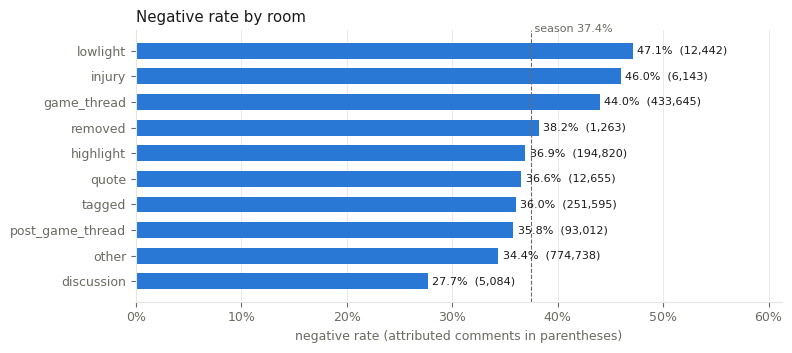

In [4]:
# §2 — the room table on the fact.
_posts_reached = fact.group_by("room").agg(pl.col("link_id").n_unique().alias("posts_reached"))
rooms_fact = rates(
    fact.group_by("room")
    .agg(pl.col("comment_count", "neg_count", "pos_count").sum())
).join(_posts_reached, on="room").join(
    rooms_bridge.select("room", "posts", "room_comments", "room_share"), on="room"
).with_columns(
    (pl.col("comment_count") / ATTRIBUTED).round(4).alias("fact_share"),
    (pl.col("comment_count") / pl.col("room_comments")).round(4).alias("density"),
    (pl.col("posts_reached") / pl.col("posts")).round(4).alias("posts_reached_share"),
).sort("comment_count", descending=True)

SEASON_NEG = fact["neg_count"].sum() / fact["comment_count"].sum()
print(f"season negative rate, all rooms: {SEASON_NEG:.1%}")
display(rooms_fact.select(
    "room", "comment_count", "fact_share", "room_share", "density",
    "neg_rate", "pos_rate", "posts_reached", "posts_reached_share",
))

_r = rooms_fact.sort("neg_rate")
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(_r["room"], _r["neg_rate"], height=0.62, color="#2a78d6")
ax.axvline(SEASON_NEG, color=MUTED, lw=0.8, ls="--")
ax.text(SEASON_NEG, len(_r) - 0.35, f" season {SEASON_NEG:.1%}", color=MUTED, fontsize=8, va="bottom")
for _y, (_v, _n) in enumerate(zip(_r["neg_rate"], _r["comment_count"])):
    ax.text(_v + 0.004, _y, f"{_v:.1%}  ({_n:,})", va="center", fontsize=8, color=INK)
ax.set_xlim(0, _r["neg_rate"].max() * 1.3)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="y", visible=False)
ax.set_xlabel("negative rate (attributed comments in parentheses)")
ax.set_title("Negative rate by room", loc="left")
plt.tight_layout()
plt.show()

## 3. The leading tag — the tail, and who carries the volume

Every unflaired post whose title opens with a bracketed tag, outside the four
convention tags §1 already names. `quote` and `tagged` are read together here because
the split between them is the alias map's, and the map was not built for titles.
The table is persisted with sample titles for a manual pass over the tag classes.

In [5]:
# §3 — tags on the bridge and on the fact.
_tag_rooms = ["tagged", "quote"]
_tag_fact = rates(
    fact.filter(pl.col("room").is_in(_tag_rooms))
    .group_by("tag")
    .agg(pl.col("comment_count", "neg_count", "pos_count").sum())
)
tags = (
    bridge.filter(pl.col("room").is_in(_tag_rooms))
    .sort("num_comments", descending=True)
    .group_by("tag", maintain_order=True)
    .agg(
        pl.col("room").first(),
        pl.col("tag_player").first(),
        pl.len().cast(pl.Int64).alias("posts"),
        pl.col("num_comments").sum().alias("room_comments"),
        pl.col("title").head(3).str.slice(0, 140).str.join(" || ").alias("sample_titles"),
    )
    .join(_tag_fact, on="tag", how="left")
    .with_columns(pl.col("comment_count", "neg_count", "pos_count").fill_null(0))
    .sort("comment_count", descending=True)
)

TAGS_CSV = COVERAGE_DIR / "title_tags.csv"
tags.write_csv(TAGS_CSV)

_tagged_total = tags["comment_count"].sum()
print(f"{tags.height:,} distinct tags; {tags.filter(pl.col('posts') == 1).height:,} appear once")
print(f"attributed comments under a tag: {_tagged_total:,} ({_tagged_total / ATTRIBUTED:.1%} of the fact)")
for _n in (1, 10, 25, 50):
    print(f"  top {_n:>2} tags hold {tags.head(_n)['comment_count'].sum() / _tagged_total:.1%}")
for _floor in (ROOM_FLOOR, 1000, QUALIFIED_BAR):
    _k = tags.filter(pl.col("comment_count") >= _floor)
    print(f"  tags with >= {_floor:,} attributed comments: {_k.height} "
          f"({_k['comment_count'].sum() / _tagged_total:.1%} of tagged volume)")
print(f"persisted: {TAGS_CSV.name}")

display(tags.select("tag", "room", "posts", "room_comments", "comment_count", "neg_rate", "pos_rate").head(30))

1,498 distinct tags; 834 appear once
attributed comments under a tag: 264,250 (14.8% of the fact)
  top  1 tags hold 23.7%
  top 10 tags hold 44.0%
  top 25 tags hold 56.7%
  top 50 tags hold 66.3%
  tags with >= 200 attributed comments: 175 (85.0% of tagged volume)
  tags with >= 1,000 attributed comments: 37 (62.2% of tagged volume)
  tags with >= 5,000 attributed comments: 6 (38.5% of tagged volume)
persisted: title_tags.csv


tag,room,posts,room_comments,comment_count,neg_rate,pos_rate
str,str,i64,i64,i64,f64,f64
"""charania""","""tagged""","1,254","272,079","62,496",0.3615,0.1757
"""stein""","""tagged""",152,"32,232","8,900",0.3743,0.1431
"""amick""","""tagged""",106,"30,152","8,822",0.3529,0.1555
"""haynes""","""tagged""",192,"27,937","7,800",0.3926,0.1579
"""fischer""","""tagged""",159,"21,865","7,165",0.3389,0.158
"""windhorst""","""tagged""",77,"21,857","6,554",0.3325,0.1547
"""scotto""","""tagged""",140,"15,520","3,857",0.3236,0.1792
"""mcmenamin""","""tagged""",71,"12,202","3,716",0.3784,0.1773
"""espn""","""tagged""",143,"15,194","3,546",0.3652,0.1726


In [6]:
# §3 — the tags the alias map reads as a player.
_quote = tags.filter(pl.col("room") == "quote")
print(f"{_quote.height} tags resolve to a tracked player; "
      f"{_quote['posts'].sum():,} posts, {_quote['comment_count'].sum():,} attributed comments")
display(_quote.select("tag", "tag_player", "posts", "comment_count", "neg_rate", "sample_titles").head(25))

# In a quote room, how much of the talk is about the player in the tag?
_q = fact.filter(pl.col("room") == "quote")
_own = _q.filter(pl.col("attributed_player") == pl.col("tag_player"))["comment_count"].sum()
print(f"attributed to the tagged player: {_own:,} of {_q['comment_count'].sum():,} "
      f"({_own / _q['comment_count'].sum():.1%})")

85 tags resolve to a tracked player; 235 posts, 12,655 attributed comments


tag,tag_player,posts,comment_count,neg_rate,sample_titles
str,str,i64,i64,f64,str
"""jaylen brown""","""Jaylen Brown""",9,"1,055",0.3507,"""[Jaylen Brown] Analytics have / are ruining the game we playing AI hoops. Nobody…"
"""sga""","""Shai Gilgeous-Alexander""",11,"1,024",0.292,"""[SGA] on if breaking the 73-win record would mean anything to him: ""Absolutely. …"
"""giannis""","""Giannis Antetokounmpo""",14,"1,001",0.3846,"""[Giannis] on being booed at home: “I was definitely booing back... I don’t think…"
"""ja morant""","""Ja Morant""",4,860,0.4488,"""[Ja Morant] when asked what went wrong and why he looked to have low energy toni…"
"""turner""","""Myles Turner""",5,824,0.4939,"""[Turner] Austin Reaves is reportedly seeking a max contract worth up to 5 years,…"
"""jayson tatum""","""Jayson Tatum""",8,805,0.395,"""[Jayson Tatum] on DNPs in the Olympics: “People didn’t take into account how I w…"
"""simmons""","""Ben Simmons""",17,648,0.338,"""[Simmons] “Giannis ONLY has 8 playoff series wins. I’m gonna put that in perspec…"
"""cade cunningham""","""Cade Cunningham""",1,546,0.3956,"""[Cade Cunningham] “The flopping is just too much…3 of the top 5-10 guys do it co…"
"""luka doncic""","""Luka Doncic""",3,498,0.2912,"""[Luka Doncic] on whether he’ll chase the MVP award: ""I just play my game. You ne…"


attributed to the tagged player: 4,497 of 12,655 (35.5%)


## 4. Players across rooms — who clears the floor, and does the order change

Qualified players only (the published bar). A player x room cell counts when it clears
the floor a player x fanbase cell must clear. Two questions: how many cells each room
fills, and whether a room's ranking is the leaderboard again or something of its own
(Spearman against the player's rate over all rooms).

In [7]:
# §4 — player x room cells.
overall = pl.read_parquet(DASHBOARD / "player_overall.parquet").filter(
    pl.col("comment_count") >= QUALIFIED_BAR
)
qualified = overall["attributed_player"].to_list()

cells = rates(
    fact.filter(pl.col("attributed_player").is_in(qualified))
    .group_by("attributed_player", "room")
    .agg(pl.col("comment_count", "neg_count", "pos_count").sum())
).join(
    overall.select("attributed_player", pl.col("neg_rate").alias("overall_neg_rate"),
                   pl.col("comment_count").alias("overall_count")),
    on="attributed_player",
).with_columns((pl.col("comment_count") / pl.col("overall_count")).round(4).alias("share_of_player"))
filled = cells.filter(pl.col("comment_count") >= ROOM_FLOOR)

coverage = (
    filled.group_by("room")
    .agg(
        pl.len().alias("players_clearing"),
        pl.col("comment_count").median().cast(pl.Int64).alias("median_cell"),
        pl.col("neg_rate").min().alias("neg_rate_min"),
        pl.col("neg_rate").median().round(4).alias("neg_rate_median"),
        pl.col("neg_rate").max().alias("neg_rate_max"),
        pl.corr("neg_rate", "overall_neg_rate", method="spearman").round(3).alias("rank_corr_overall"),
    )
    .sort("players_clearing", descending=True)
)
print(f"{len(qualified)} qualified players; floor {ROOM_FLOOR} comments per player x room cell")
display(coverage)

print("share of a qualified player's comments by room (median, min, max across players)")
display(
    cells.group_by("room")
    .agg(
        pl.col("share_of_player").median().round(4).alias("median_share"),
        pl.col("share_of_player").min().alias("min_share"),
        pl.col("share_of_player").max().alias("max_share"),
    )
    .sort("median_share", descending=True)
)

67 qualified players; floor 200 comments per player x room cell


room,players_clearing,median_cell,neg_rate_min,neg_rate_median,neg_rate_max,rank_corr_overall
str,u32,i64,f64,f64,f64,f64
"""game_thread""",67,"2,688",0.1642,0.4292,0.6894,0.773
"""other""",67,"5,498",0.1509,0.3645,0.5217,0.93
"""highlight""",67,"1,431",0.1343,0.365,0.5871,0.853
"""tagged""",67,"1,683",0.1498,0.3463,0.5123,0.787
"""post_game_thread""",65,708,0.1103,0.3676,0.577,0.888
"""quote""",16,490,0.1818,0.3909,0.5069,0.538
"""lowlight""",15,336,0.3932,0.4716,0.5725,0.814
"""injury""",8,342,0.2794,0.5384,0.6796,0.667
"""discussion""",4,384,0.1398,0.2415,0.2844,1.0


share of a qualified player's comments by room (median, min, max across players)


room,median_share,min_share,max_share
str,f64,f64,f64
"""other""",0.4209,0.2484,0.6342
"""game_thread""",0.248,0.0246,0.5631
"""tagged""",0.133,0.0325,0.3967
"""highlight""",0.1013,0.0523,0.2428
"""post_game_thread""",0.0546,0.0197,0.0969
"""lowlight""",0.0063,0.001,0.0237
"""quote""",0.0045,0.0002,0.0438
"""discussion""",0.0023,0.0005,0.0124
"""injury""",0.002,0.0003,0.0318


In [8]:
# §4 — the top of each room, and the players whose rooms disagree most.
print("most negative three per room (cells clearing the floor)")
display(
    filled.sort("neg_rate", descending=True)
    .group_by("room", maintain_order=True)
    .head(3)
    .select("room", "attributed_player", "comment_count", "neg_rate", "overall_neg_rate")
    .sort("room", "neg_rate", descending=[False, True])
)

_BIG = ["game_thread", "post_game_thread", "highlight", "tagged", "other"]
spread = (
    filled.filter(pl.col("room").is_in(_BIG))
    .group_by("attributed_player")
    .agg(
        pl.len().alias("rooms"),
        pl.col("neg_rate").max().alias("max_rate"),
        pl.col("neg_rate").min().alias("min_rate"),
        pl.col("room").sort_by("neg_rate").last().alias("harshest_room"),
        pl.col("room").sort_by("neg_rate").first().alias("kindest_room"),
    )
    .filter(pl.col("rooms") == len(_BIG))
    .with_columns((pl.col("max_rate") - pl.col("min_rate")).round(4).alias("spread"))
    .sort("spread", descending=True)
)
print(f"{spread.height} qualified players clear the floor in all five large rooms")
print(f"spread between a player's harshest and kindest room: median "
      f"{spread['spread'].median():.1%}, max {spread['spread'].max():.1%}")
display(spread.group_by("harshest_room").len().sort("len", descending=True))
display(spread.group_by("kindest_room").len().sort("len", descending=True))
display(spread.head(10))

most negative three per room (cells clearing the floor)


room,attributed_player,comment_count,neg_rate,overall_neg_rate
str,str,i64,f64,f64
"""discussion""","""Shai Gilgeous-Alexander""",443,0.2844,0.377
"""discussion""","""LeBron James""",326,0.2822,0.3477
"""discussion""","""Stephen Curry""",239,0.2008,0.3018
"""game_thread""","""James Harden""","11,572",0.6894,0.5532
"""game_thread""","""Julius Randle""","4,256",0.6391,0.5233
"""game_thread""","""De'Aaron Fox""","16,289",0.5879,0.5216
"""highlight""","""Lu Dort""","4,510",0.5871,0.5321
"""highlight""","""Ja Morant""","1,442",0.5811,0.4595
"""highlight""","""Draymond Green""","6,360",0.5642,0.5261


65 qualified players clear the floor in all five large rooms
spread between a player's harshest and kindest room: median 13.5%, max 27.5%


harshest_room,len
str,u32
"""game_thread""",45
"""highlight""",8
"""post_game_thread""",5
"""tagged""",5
"""other""",2


kindest_room,len
str,u32
"""tagged""",22
"""highlight""",16
"""other""",12
"""post_game_thread""",11
"""game_thread""",4


attributed_player,rooms,max_rate,min_rate,harshest_room,kindest_room,spread
str,u32,f64,f64,str,str,f64
"""Isaiah Hartenstein""",5,0.5397,0.2647,"""game_thread""","""tagged""",0.275
"""Austin Reaves""",5,0.5729,0.3066,"""game_thread""","""tagged""",0.2663
"""Jalen Duren""",5,0.573,0.3518,"""game_thread""","""tagged""",0.2212
"""Klay Thompson""",5,0.5483,0.3273,"""game_thread""","""highlight""",0.221
"""Devin Booker""",5,0.5323,0.3158,"""game_thread""","""tagged""",0.2165
"""James Harden""",5,0.6894,0.4733,"""game_thread""","""tagged""",0.2161
"""Cade Cunningham""",5,0.4292,0.2139,"""game_thread""","""tagged""",0.2153
"""Josh Hart""",5,0.4841,0.2706,"""game_thread""","""other""",0.2135
"""Julius Randle""",5,0.6391,0.4303,"""game_thread""","""highlight""",0.2088


### 4b. The leaderboard under one room mix

Game threads are harsher than every other room, and a player's share of comments
posted there runs from 2% to 56%. So part of any overall rate is the mix. Direct
standardization: each player's rate per room, weighted by the qualified players'
pooled mix, small rooms folded into `rest`. The question is how far the order moves.

In [9]:
# §4b — room-standardized negative rate.
_std_cells = (
    fact.filter(pl.col("attributed_player").is_in(qualified))
    .with_columns(
        pl.when(pl.col("room").is_in(_BIG)).then(pl.col("room")).otherwise(pl.lit("rest")).alias("stack")
    )
    .group_by("attributed_player", "stack")
    .agg(pl.col("comment_count", "neg_count").sum())
)
_weights = (
    _std_cells.group_by("stack")
    .agg(pl.col("comment_count").sum())
    .with_columns((pl.col("comment_count") / pl.col("comment_count").sum()).alias("weight"))
    .select("stack", "weight")
)
display(_weights.sort("weight", descending=True).with_columns(pl.col("weight").round(4)))

standardized = (
    _std_cells.join(_weights, on="stack")
    .group_by("attributed_player")
    .agg(
        (pl.col("neg_count") / pl.col("comment_count") * pl.col("weight")).sum().alias("num"),
        pl.col("weight").sum().alias("covered"),
        pl.col("comment_count").min().alias("smallest_cell"),
    )
    .with_columns((pl.col("num") / pl.col("covered")).round(4).alias("std_neg_rate"))
    .join(
        cells.filter(pl.col("room") == "game_thread")
        .select("attributed_player", pl.col("share_of_player").alias("game_thread_share")),
        on="attributed_player", how="left",
    )
    .join(overall.select("attributed_player", "comment_count", "neg_rate"), on="attributed_player")
    .with_columns(
        pl.col("neg_rate").rank("ordinal", descending=True).cast(pl.Int64).alias("rank"),
        pl.col("std_neg_rate").rank("ordinal", descending=True).cast(pl.Int64).alias("std_rank"),
        (pl.col("std_neg_rate") - pl.col("neg_rate")).round(4).alias("shift"),
    )
    .with_columns((pl.col("rank") - pl.col("std_rank")).alias("places_gained"))
    .select("attributed_player", "comment_count", "game_thread_share", "neg_rate",
            "std_neg_rate", "shift", "rank", "std_rank", "places_gained", "smallest_cell")
)
print(f"rank correlation, overall vs standardized: "
      f"{standardized.select(pl.corr('neg_rate', 'std_neg_rate', method='spearman')).item():.3f}")
print(f"shift in rate: median {standardized['shift'].median():+.1%}, "
      f"min {standardized['shift'].min():+.1%}, max {standardized['shift'].max():+.1%}")
print(f"players moving 5+ places: {standardized.filter(pl.col('places_gained').abs() >= 5).height}")

print("the top ten, standardized")
display(standardized.sort("std_rank").head(10))
print("largest moves")
display(standardized.sort(pl.col("places_gained").abs(), descending=True).head(10))

stack,weight
str,f64
"""other""",0.4463
"""game_thread""",0.2387
"""tagged""",0.1357
"""highlight""",0.1094
"""post_game_thread""",0.0484
"""rest""",0.0216


rank correlation, overall vs standardized: 0.974
shift in rate: median -0.6%, min -4.9%, max +3.3%
players moving 5+ places: 13
the top ten, standardized


attributed_player,comment_count,game_thread_share,neg_rate,std_neg_rate,shift,rank,std_rank,places_gained,smallest_cell
str,i64,f64,f64,f64,f64,i64,i64,i64,i64
"""James Harden""","40,814",0.2835,0.5532,0.5453,-0.0079,1,1,0,666
"""Draymond Green""","27,187",0.101,0.5261,0.5232,-0.0029,3,2,1,810
"""Lu Dort""","19,745",0.3058,0.5321,0.5182,-0.0139,2,3,-1,626
"""Deandre Ayton""","12,931",0.2987,0.4995,0.4915,-0.008,7,4,3,182
"""Julius Randle""","10,577",0.4024,0.5233,0.4911,-0.0322,4,5,-1,106
"""Russell Westbrook""","14,612",0.0583,0.4761,0.4892,0.0131,9,6,3,280
"""De'Aaron Fox""","35,977",0.4528,0.5216,0.486,-0.0356,5,7,-2,396
"""Chet Holmgren""","28,500",0.3992,0.5024,0.4809,-0.0215,6,8,-2,617
"""Alperen Sengun""","9,836",0.4099,0.4965,0.4724,-0.0241,8,9,-1,108


largest moves


attributed_player,comment_count,game_thread_share,neg_rate,std_neg_rate,shift,rank,std_rank,places_gained,smallest_cell
str,i64,f64,f64,f64,f64,i64,i64,i64,i64
"""Klay Thompson""","6,660",0.0731,0.3766,0.41,0.0334,39,22,17,148
"""Isaiah Hartenstein""","6,761",0.4489,0.4443,0.3958,-0.0485,16,28,-12,201
"""Josh Hart""","9,599",0.4573,0.3814,0.3362,-0.0452,35,47,-12,154
"""Stephon Castle""","19,337",0.5631,0.3962,0.3498,-0.0464,31,42,-11,406
"""LeBron James""","111,720",0.1121,0.3477,0.3607,0.013,48,40,8,"1,899"
"""Trae Young""","12,534",0.0516,0.4425,0.4547,0.0122,17,10,7,312
"""Jaylen Brown""","20,510",0.1646,0.3733,0.3836,0.0103,41,34,7,604
"""LaMelo Ball""","13,123",0.1209,0.4382,0.4525,0.0143,18,12,6,585
"""Alex Caruso""","14,680",0.5304,0.4009,0.3821,-0.0188,30,36,-6,254


## 5. The season's rhythm — room mix by month

Attributed comments by the month their post was created (UTC), stacked by room. The
small rooms are folded into `rest` so the stack stays readable; the table carries
every room.

month,game_thread,post_game_thread,highlight,tagged,other,rest,total
date,i64,i64,i64,i64,i64,i64,i64
2025-10-01,"21,560","6,537","14,567","13,837","46,884","2,673","106,058"
2025-11-01,"19,640","11,976","22,594","24,665","71,024","2,942","152,841"
2025-12-01,"27,799","10,981","26,499","26,129","74,038","6,164","171,610"
2026-01-01,"14,779","10,723","19,136","28,928","63,367","5,263","142,196"
2026-02-01,"19,287","7,234","18,675","34,827","67,640","2,975","150,638"
2026-03-01,"19,440","8,589","24,132","16,432","74,984","2,343","145,920"
2026-04-01,"74,693","13,069","23,349","23,613","101,653","4,922","241,299"
2026-05-01,"164,163","16,055","32,060","31,126","154,287","5,266","402,957"
2026-06-01,"72,284","7,848","13,808","52,038","120,861","5,039","271,878"


month,game_thread,post_game_thread,highlight,tagged,other,rest
date,f64,f64,f64,f64,f64,f64
2025-10-01,0.203,0.062,0.137,0.13,0.442,0.025
2025-11-01,0.128,0.078,0.148,0.161,0.465,0.019
2025-12-01,0.162,0.064,0.154,0.152,0.431,0.036
2026-01-01,0.104,0.075,0.135,0.203,0.446,0.037
2026-02-01,0.128,0.048,0.124,0.231,0.449,0.02
2026-03-01,0.133,0.059,0.165,0.113,0.514,0.016
2026-04-01,0.31,0.054,0.097,0.098,0.421,0.02
2026-05-01,0.407,0.04,0.08,0.077,0.383,0.013
2026-06-01,0.266,0.029,0.051,0.191,0.445,0.019


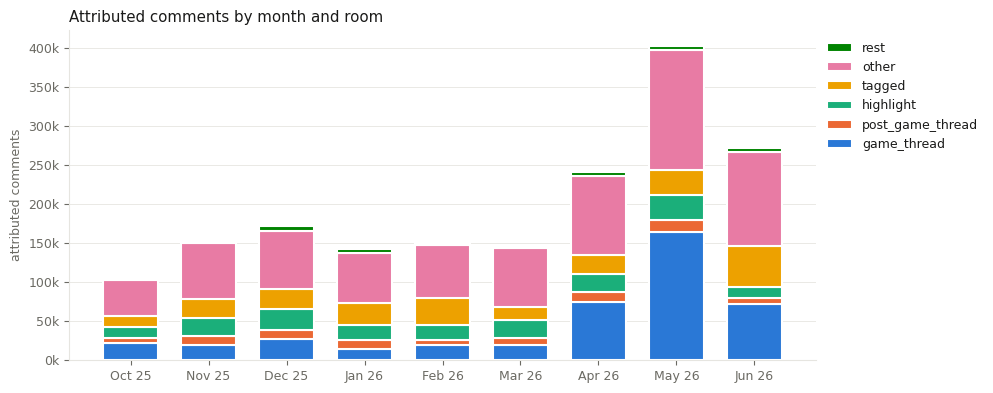

In [10]:
# §5 — monthly mix.
_FOLD = {"quote": "rest", "lowlight": "rest", "injury": "rest", "discussion": "rest", "removed": "rest"}
STACK = ["game_thread", "post_game_thread", "highlight", "tagged", "other", "rest"]
COLORS = dict(zip(STACK, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]))

monthly = (
    fact.with_columns(
        pl.from_epoch("created_utc", time_unit="s").dt.truncate("1mo").dt.date().alias("month"),
        pl.col("room").replace(_FOLD).alias("stack"),
    )
    .group_by("month", "stack")
    .agg(pl.col("comment_count", "neg_count").sum())
    .sort("month")
)
wide = (
    monthly.pivot(on="stack", index="month", values="comment_count")
    .fill_null(0)
    .select("month", *STACK)
    .sort("month")
)
wide = wide.with_columns(pl.sum_horizontal(STACK).alias("total"))
display(wide)
display(
    wide.select(
        "month",
        *[(pl.col(c) / pl.col("total")).round(3).alias(c) for c in STACK],
    )
)

_labels = [m.strftime("%b %y") for m in wide["month"]]
fig, ax = plt.subplots(figsize=(10, 4))
_bottom = [0] * wide.height
for _room in STACK:
    _vals = wide[_room].to_list()
    ax.bar(_labels, _vals, bottom=_bottom, width=0.7, color=COLORS[_room],
           edgecolor=SURFACE, linewidth=1.5, label=_room)
    _bottom = [b + v for b, v in zip(_bottom, _vals)]
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:.0f}k")
ax.grid(axis="x", visible=False)
ax.set_ylabel("attributed comments")
ax.set_title("Attributed comments by month and room", loc="left")
_h, _l = ax.get_legend_handles_labels()
ax.legend(_h[::-1], _l[::-1], frameon=False, bbox_to_anchor=(1.0, 1.0), loc="upper left")
plt.tight_layout()
plt.show()

## Findings

**The rooms**

- **The bridge was a fair proxy.** Every room's share of the fact sits within about
  three points of its share of whole-room comments. The site sees about a quarter of any
  room (density 0.21 to 0.29).
- **Game threads are the harsh room.** 44.0% negative against a season rate of 37.4%,
  and the harshest of the five large rooms for 45 of 65 players.
- **Highlight is not a positive baseline.** 36.9% negative and 27.3% positive, which is
  the season again. Post-game threads carry the highest positive rate of the large
  rooms (32.6%).
- **Injury and lowlight are the two most negative rooms** (46.0% and 47.1%) and the
  least positive. The classifier does not read injury rooms as sympathy. Whether the
  negativity there is aimed at the player is a question for the target verdicts, not
  for this notebook.

**The tags**

- **The tail is long and the head is one reporter.** 1,498 distinct tags, 834 of them
  used once. Charania holds 23.7% of tagged volume; 37 tags clear 1,000 attributed
  comments and 6 clear the qualified bar.
- **Sources barely differ.** The thirty largest tags run 27% to 47% negative, most of
  them within five points of the season rate. The league's own tags (`nba.com`, `nba`)
  are the kindest at 27 to 28%.
- **A leading tag is not always a source.** 85 tags resolve to a tracked player. Full
  names and nicknames are quotes (`[Jaylen Brown]`, `[SGA]`); bare surnames are mostly
  writers the alias map misreads (`[Simmons]`, `[Turner]`, `[Bailey]`, `[Poole]`,
  `[Harper]`). The tag classes need a manual pass over `title_tags.csv` before a rule
  is written.
- **Quote is not a room on volume.** 0.7% of the fact, and only 35.5% of it is about
  the player quoted.

**The players**

- **Five rooms fill a player grid:** `game_thread`, `highlight`, `tagged` and `other`
  for all 67 qualified players, `post_game_thread` for 65. `lowlight` (15), `injury`
  (8), `quote` (16) and `discussion` (4) do not; they are league-level numbers only.
- **Players differ by room.** The median gap between a player's harshest and kindest
  large room is 13.5 points, the widest 27.5.
- **`other` is the leaderboard again** (rank correlation 0.93 with the overall rate).
  Game threads and tagged posts have an order of their own (0.77 and 0.79).
- **The leaderboard survives the mix.** With every player held to one room mix, the
  order correlates 0.974 with the published one and the top nine are the same nine
  players. Rates shift by at most five points. 13 of 67 players move five or more
  places: role players on deep playoff teams fall (Hartenstein, Hart, Castle), players
  seldom discussed in game threads rise (Thompson, Young).

**The season**

- **Game threads swell in the playoffs:** 10% to 20% of the fact in a regular-season
  month, 31% in April and 41% in May.
- **Tagged posts peak around the trade deadline and after the Finals:** 20.3% of
  January, 23.1% of February and 19.1% of June, against 8% to 16% in the other months.

**What follows for the wider `post_type`**

- The five large rooms carry a per-player cut. The small rooms are worth their types
  for league-level figures and for filtering, not for a grid.
- `source` holds up as a column. As a displayed dimension it is Charania and a handful.
- The `news` rule cannot be "any leading tag". It needs the tag classes decided first:
  reporter, outlet, show, player quote, and the conventions that are none of these.